In [1]:
import os
import h5py
import mediapy as media
import matplotlib.pyplot as plt
import numpy as np

def load_hdf5(dataset_path):
    if not os.path.isfile(dataset_path):
        print(f'Dataset does not exist at \n{dataset_path}\n')
        exit()

    with h5py.File(dataset_path, 'r') as root:
        qpos = root['/observations/qpos'][()]
        qvel = root['/observations/qvel'][()]
        key_frame = None
        if '/observations/key_frame' in root:
            key_frame = root['/observations/key_frame'][()]
        image_dict = dict()
        for cam_name in root[f'/observations/images/'].keys():
            image_dict[cam_name] = root[f'/observations/images/{cam_name}'][()]
        action = root['/action'][()]

    return qpos, qvel, action, image_dict, key_frame

/home/vivekbagade/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [38]:
# play cam video
data_file = '/media/vivekbagade/Elements/act-data/PickPlaceCan/episodes/5.1.0-sim/episode_2.hdf5'
qpos, qvel, action, image_dict, key_frames = load_hdf5(dataset_path=data_file)

# episode stats
with h5py.File(data_file, 'r') as root:
    attrs = dict(root.attrs)
num_steps = len(action)
real_len = attrs.get('real_len', num_steps)
print('--- Episode stats ---')
print(f'Number of steps: {num_steps}')
print(f'Real len:        {real_len} ({real_len / num_steps:.1%} of steps)')
print(f'Action dim:      {action.shape[1]}')
print(f'qpos dim:        {qpos.shape[1]}, qvel dim: {qvel.shape[1]}')
if key_frames is not None:
    print(f'Key frames:      {int(np.sum(key_frames))}')
for cam_name, image_list in image_dict.items():
    print(f'Camera {cam_name}: {image_list.shape}, {image_list.dtype}')
for k, v in attrs.items():
    if k != 'real_len':
        print(f'Attr {k}: {v}')
print('---------------------')

for cam_name, image_list in image_dict.items():
    print(cam_name)
    if cam_name == 'frontview':
        # Rotate each frame 180 degrees
        image_list = np.flip(image_list, axis=(1, 2))
    media.show_video(image_list, fps=30)

--- Episode stats ---
Number of steps: 800
Real len:        800 (100.0% of steps)
Action dim:      7
qpos dim:        8, qvel dim: 8
Key frames:      16
Camera birdview: (800, 256, 256, 3), uint8
Camera frontview: (800, 256, 256, 3), uint8
Camera robot0_eye_in_hand: (800, 256, 256, 3), uint8
Attr sim: True
---------------------
birdview


This browser does not support the video tag.


frontview


This browser does not support the video tag.


robot0_eye_in_hand


This browser does not support the video tag.


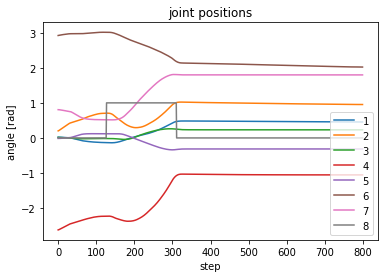

In [36]:
# plot qpos
plt.figure()
plt.plot(qpos, label=list(range(1, 9)))
plt.xlabel('step')
plt.ylabel('angle [rad]')
plt.title('joint positions')
plt.legend()

Action Vector len: 7


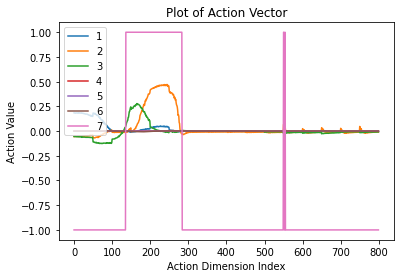

In [34]:
print("Action Vector len:", len(action[0]))
plt.figure()
plt.plot(action, label=list(range(1, 8)))
plt.xlabel("Action Dimension Index")
plt.ylabel("Action Value")
plt.title("Plot of Action Vector")
plt.legend()


Number of key frames: 39
Key frames for camera: birdview
Key frame at index 111


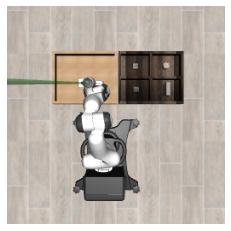

Key frame at index 153


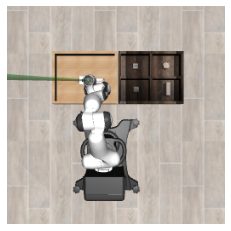

Key frame at index 179


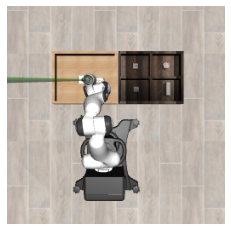

Key frame at index 187


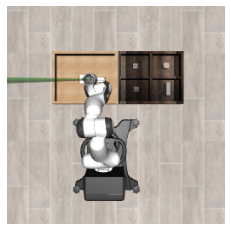

Key frame at index 194


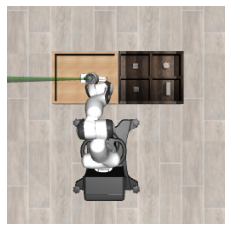

Key frame at index 200


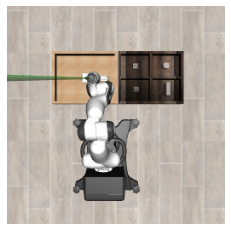

Key frame at index 399


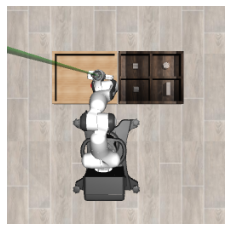

Key frame at index 498


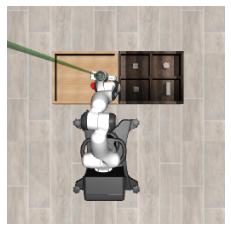

Key frame at index 597


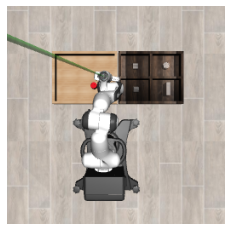

Key frame at index 629


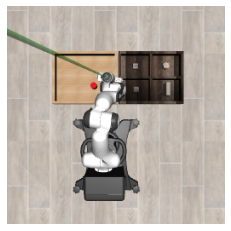

Key frames for camera: frontview
(256, 256, 3) uint8
Key frame at index 111


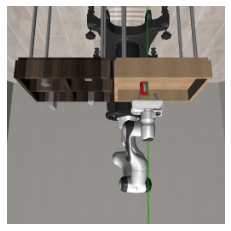

(256, 256, 3) uint8
Key frame at index 153


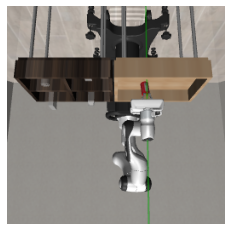

(256, 256, 3) uint8
Key frame at index 179


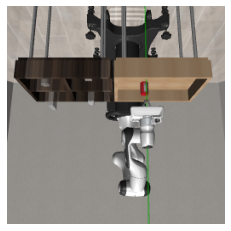

(256, 256, 3) uint8
Key frame at index 187


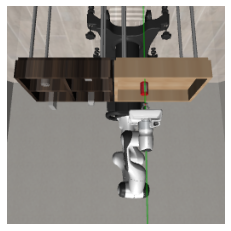

(256, 256, 3) uint8
Key frame at index 194


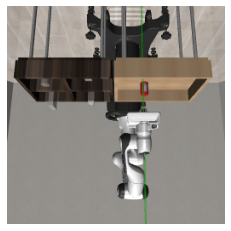

(256, 256, 3) uint8
Key frame at index 200


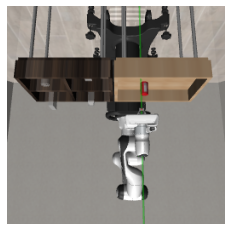

(256, 256, 3) uint8
Key frame at index 399


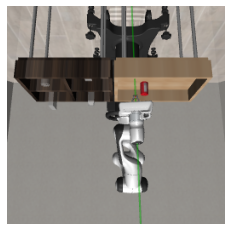

(256, 256, 3) uint8
Key frame at index 498


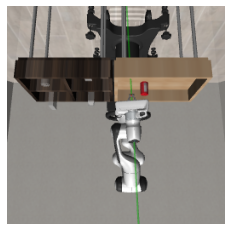

(256, 256, 3) uint8
Key frame at index 597


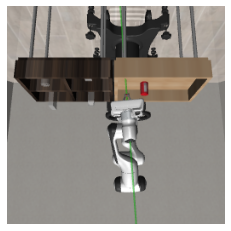

(256, 256, 3) uint8
Key frame at index 629


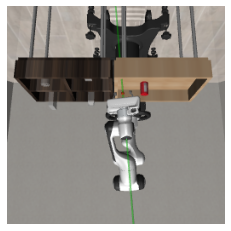

Key frames for camera: robot0_eye_in_hand
Key frame at index 111


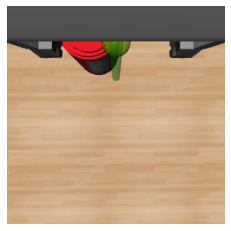

Key frame at index 153


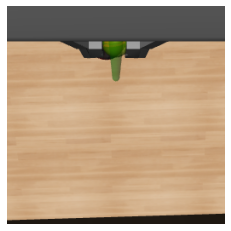

Key frame at index 179


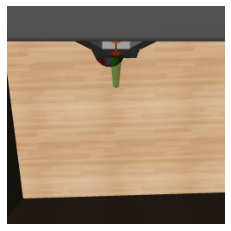

Key frame at index 187


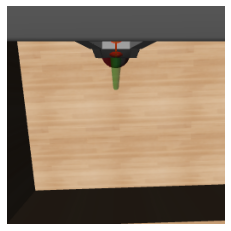

Key frame at index 194


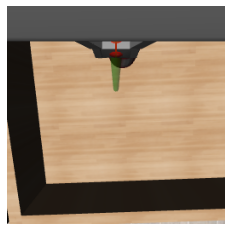

Key frame at index 200


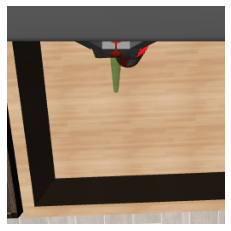

Key frame at index 399


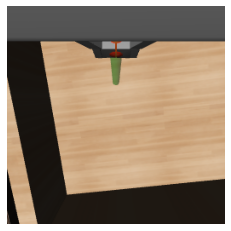

Key frame at index 498


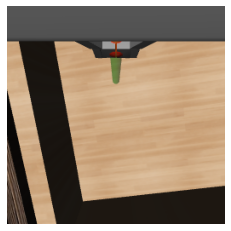

Key frame at index 597


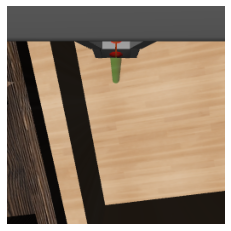

Key frame at index 629


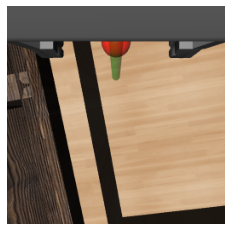

In [9]:
import numpy as np

num_key_frames = 0
for i in range(len(key_frames)):
    if key_frames[i]:
        num_key_frames += 1
print(f'Number of key frames: {num_key_frames}')

## Print the images of the indices where key_frames is True
max_frames = 10
for cam_name, image_list in image_dict.items():
    min_diff = 5
    last_key_frame = -min_diff
    print(f'Key frames for camera: {cam_name}')
    cur = 0
    for i in range(len(key_frames)):
        if key_frames[i] and (i - last_key_frame) >= min_diff:
            last_key_frame = i
            if cur >= max_frames:
                break
            cur += 1
            final = image_list[i]
            if cam_name == 'frontview':
                # Rotate the image 180 degrees
                print(final.shape, final.dtype)
                final = np.flip(final, axis=1)
            print(f'Key frame at index {i}')
            plt.figure()
            plt.imshow(final)
            plt.axis('off')
            plt.show()